In [1]:
# 필요한 라이브러리 정리
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.linear_model import ElasticNet, Lasso, Ridge, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
# 데이터 로드
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.info()

test_id = test['Id']  # 제출용

train = train.drop('Id', axis=1)
test = test.drop('Id', axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1168 entries, 0 to 1167
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    950 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          70 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallC

## 결측치 처리

In [3]:
missing = train.isnull().mean().sort_values(ascending=False)
missing.head(20)

PoolQC          0.994863
MiscFeature     0.958904
Alley           0.940068
Fence           0.805651
MasVnrType      0.594178
FireplaceQu     0.466610
LotFrontage     0.186644
GarageYrBlt     0.059075
GarageCond      0.059075
GarageType      0.059075
GarageFinish    0.059075
GarageQual      0.059075
BsmtExposure    0.020548
BsmtFinType2    0.020548
BsmtCond        0.019692
BsmtQual        0.019692
BsmtFinType1    0.019692
MasVnrArea      0.006849
Electrical      0.000856
MSSubClass      0.000000
dtype: float64

In [4]:
missing = test.isnull().mean().sort_values(ascending=False)
missing.head(20)

PoolQC          0.996575
MiscFeature     0.979452
Alley           0.928082
Fence           0.815068
MasVnrType      0.609589
FireplaceQu     0.496575
LotFrontage     0.140411
BsmtExposure    0.047945
BsmtQual        0.047945
BsmtCond        0.047945
BsmtFinType2    0.047945
BsmtFinType1    0.047945
GarageYrBlt     0.041096
GarageFinish    0.041096
GarageType      0.041096
GarageQual      0.041096
GarageCond      0.041096
MSSubClass      0.000000
TotRmsAbvGrd    0.000000
Functional      0.000000
dtype: float64

In [5]:
none_cols = [
    'PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
    'GarageType','GarageFinish','GarageQual','GarageCond',
    'BsmtQual','BsmtCond','BsmtExposure',
    'BsmtFinType1','BsmtFinType2'
]

for c in none_cols:
    train[c] = train[c].fillna('None')
    test[c] = test[c].fillna('None')

- 결측치가 정보를 가지고 있는 컬럼들은 None 으로 대체

In [6]:
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage']\
                           .transform(lambda x: x.fillna(x.median()))

test['LotFrontage'] = test.groupby('Neighborhood')['LotFrontage']\
                         .transform(lambda x: x.fillna(x.median()))

- LotFrontage는 도로에 접한 토지 길이
- 부동산 정보를 반영하여 그 지역의 중위수로 대체

In [7]:
train['MasVnrType'] = train['MasVnrType'].fillna('None')
test['MasVnrType'] = test['MasVnrType'].fillna('None')

train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)

train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)

train['Electrical'].fillna(train['Electrical'].mode()[0], inplace=True)

/var/folders/q3/hz0fg47j4_g8nqffrmt9hlc00000gn/T/ipykernel_26531/1416933057.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Electrical'].fillna(train['Electrical'].mode()[0], inplace=True)


- 기타 결측치 처리

## 베이스라인 모델
- 엘라스틱넷

In [8]:
def preprocess(train, test):
    y = np.log1p(train['SalePrice'])
    train2 = train.drop('SalePrice', axis=1)

    full = pd.concat([train2, test], axis=0, ignore_index=True)

    num_cols = full.select_dtypes(include=['int64','float64']).columns
    full[num_cols] = full[num_cols].fillna(full[num_cols].median())

    cat_cols = full.select_dtypes(include='object').columns
    for c in cat_cols:
        full[c] = full[c].fillna('None')

    full = pd.get_dummies(full)

    X = full.iloc[:len(train)]
    X_test = full.iloc[len(train):]

    return X, X_test, y


def evaluate_model(model, X, y, cv):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring={'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'},
        n_jobs=-1
    )

    rmse = -scores['test_rmse']
    r2 = scores['test_r2']

    print(f'RMSE: {rmse.mean():.4f} std: {rmse.std():.4f}')
    print(f'R²:   {r2.mean():.4f} std: {r2.std():.4f}')

In [9]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 베이스라인 모델(ElasticNet)
model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter=20000,
    random_state=42
)

# 전처리
X, X_test, y = preprocess(train, test)

# 모델 평가
evaluate_model(model, X, y, cv)

RMSE: 0.1882 std: 0.0222
R²:   0.7742 std: 0.0378


## 이상치 제거
- 잔차를 표준화하여 3SD이상의 값을 이상치로 간주하여 제거 (모델이 설명하지 못한 데이터 제거)

<Axes: xlabel='SalePrice', ylabel='Count'>

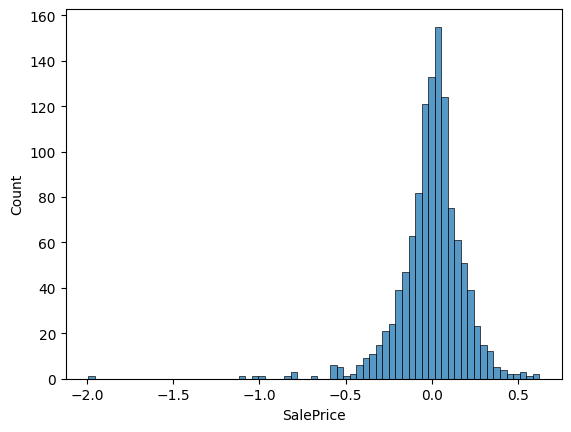

In [10]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])

pred = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)

residual = y - pred
sns.histplot(residual)

In [11]:
X, X_test, y = preprocess(train, test)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])

oof_pred = cross_val_predict(
    pipe,
    X,
    y,
    cv=5,
    n_jobs=-1
)

residual = y - oof_pred
z = (residual - residual.mean()) / residual.std()

outliers = np.abs(z) > 3

train = train.loc[~outliers].copy()

print("removed:", outliers.sum())
print("ratio:", outliers.mean())

removed: 13
ratio: 0.01113013698630137


In [12]:
X, X_test, y = preprocess(train, test)
evaluate_model(model, X, y, cv)

RMSE: 0.1518 std: 0.0130
R²:   0.8422 std: 0.0204


- 이상치 제거로 RMSE가 .1882 -> .1518로 감소하고 편차도 감소했다.

## 피처 엔지니어링
- 편포한 피처들을 로그변환하여 정규분포화
- MSSubClass 피처 범주형 변인화

In [13]:
skew_cols = ['LotArea','TotalBsmtSF']

for col in skew_cols:
    train[col] = np.log1p(train[col])
    test[col] = np.log1p(test[col])

X, X_test, y = preprocess(train, test)
evaluate_model(model, X, y, cv)

RMSE: 0.1527 std: 0.0123
R²:   0.8403 std: 0.0197


- RMSE가 .1518 -> .1527로 성능이 낮아짐

## 모델 비교
- 베이스라인 모델(엘라스틱넷)과 다른 모델을 비교하여 더 나은 모델을 선택

In [14]:
def compare_models(X, y):
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    models = {
        'ElasticNet': ElasticNet(alpha=0.05, l1_ratio=0.7, max_iter=10000, random_state=42),
        'Ridge': Ridge(alpha=10, random_state=42),
        'Lasso': Lasso(alpha=0.001, max_iter=10000, random_state=42),
        'RandomForest': RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        )
    }

    results = []

    for name, model in models.items():
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

        scores = cross_validate(
            pipe,
            X,
            y,
            cv=cv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )

        rmse = -scores['test_score']

        results.append({
            'Model': name,
            'RMSE_mean': rmse.mean(),
            'RMSE_std': rmse.std()
        })

    return pd.DataFrame(results).sort_values('RMSE_mean')

In [15]:
results = compare_models(X, y)
print(results)

          Model  RMSE_mean  RMSE_std
2         Lasso   0.104381  0.007195
1         Ridge   0.111912  0.008785
3  RandomForest   0.131853  0.010371
0    ElasticNet   0.137048  0.011555


- 모델 비교 결과 Lasso 모델의 성능이 가장 좋았음

### Lasso 모델 하이퍼파라미터 튜닝

In [16]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(
        alphas=np.logspace(-5, -1, 400),
        cv=5,
        max_iter=20000,
        n_jobs=-1
    ))
])

pipe.fit(X, y)

alpha_tuned = pipe.named_steps['lasso'].alpha_

print("best alpha:", alpha_tuned)

best alpha: 0.0035185677257392627


In [17]:
model = Lasso(alpha=alpha_tuned, max_iter=10000, random_state=42)
evaluate_model(model, X, y, cv)

RMSE: 0.1009 std: 0.0075
R²:   0.9304 std: 0.0067


In [18]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])

pipe.fit(X, y)

pred_log = pipe.predict(X_test)
pred = np.expm1(pred_log)
pred = np.clip(pred, 0, None)

submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': pred
})

submission.to_csv('submission.csv', index=False)

### kaggle score : 19790.13014 

## 앙상블 모델

In [19]:
X, X_test, y = preprocess(train, test)

# 1) 모델 정의
lasso = Lasso(alpha=alpha_tuned, max_iter=20000, random_state=42)

gbm = GradientBoostingRegressor(
    n_estimators=1200,
    learning_rate=0.01,
    max_depth=6,
    random_state=42
)

# 2) Lasso는 스케일링 포함 파이프라인으로 학습
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lasso)
])

lasso_pipe.fit(X, y)

# 3) GBM은 스케일링 없이 학습
gbm.fit(X, y)

# 4) test 예측 (log 스케일)
pred_lasso_log = lasso_pipe.predict(X_test)
pred_gbm_log = gbm.predict(X_test)

In [20]:
w_lasso = 0.8
w_gbm = 0.2
pred_ens_log = w_lasso * pred_lasso_log + w_gbm * pred_gbm_log

# 원래 스케일 복구
pred = np.expm1(pred_ens_log)

# 음수 방지
pred = np.clip(pred, 0, None)

# 제출 파일 생성
submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': pred
})

submission.to_csv('submission_ens.csv', index=False)